In [32]:
using JLD2
using CairoMakie
using SP2TExtra
using Statistics
alpha = 0.7

0.7

## View inference results

In [61]:
# chain = load("2026-05-21_inf_beads/chain_15.jld2", "chain")
chain = load("2026-05-25_inf_beads/chain_15.jld2", "chain")
frames = load("./200nm_40ms_251_362_324x250p1_1.jld2", "frames")
period = 20e-6
batchsize = 15
pixel_size = 0.1
detector_size = 55
dt = period*batchsize
println(length(chain.samples))

4001


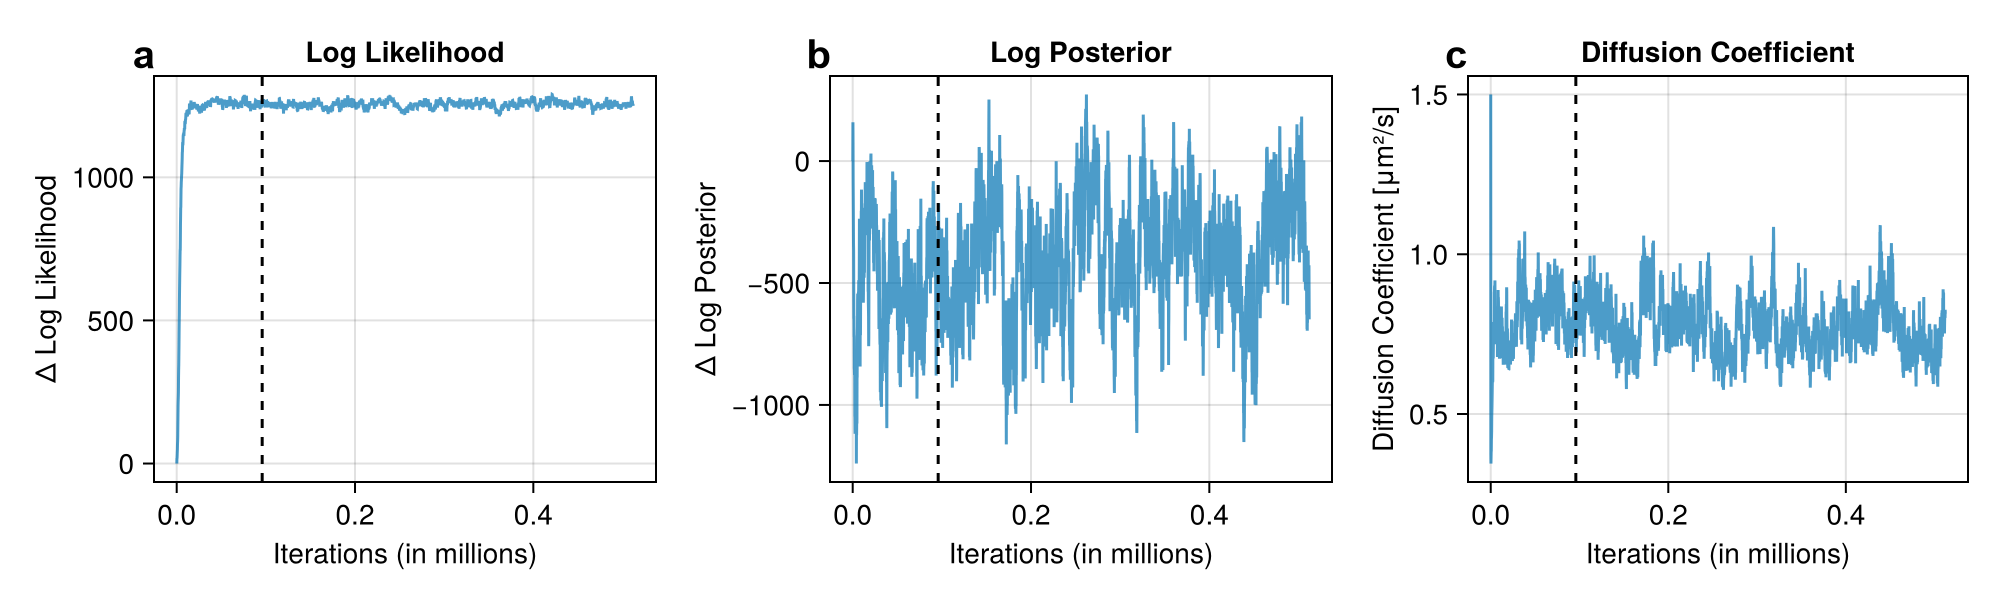

CairoMakie.Screen{IMAGE}


In [62]:
# Convergence
iterations = [s.iteration for s in chain.samples] ./1e6
burn_in = 750

# # Find burn_in_it
# idx = searchsortedfirst(iterations, burn_in_it)
# println(idx, " ", iterations[idx])

fig = Figure(size=(1000, 300))
ax1 = Axis(fig[1,1], 
    title = "Log Likelihood", 
    xlabel = "Iterations (in millions)", 
    ylabel = "Δ Log Likelihood"
)
lines!(ax1, iterations, chain.loglikelihoods .- chain.loglikelihoods[2], alpha=alpha)
vlines!(ax1, iterations[burn_in], color=:black, linestyle=:dash)

ax2 = Axis(fig[1,2], 
    title = "Log Posterior", 
    xlabel = "Iterations (in millions)", 
    ylabel = "Δ Log Posterior"
)
shift_logpost =  chain.logposteriors .- chain.logposteriors[2]
lines!(ax2, iterations, shift_logpost, alpha=alpha)
vlines!(ax2, iterations[burn_in], color=:black, linestyle=:dash)

ax3 = Axis(fig[1,3], 
    title = "Diffusion Coefficient", 
    xlabel = "Iterations (in millions)", 
    ylabel = "Diffusion Coefficient [μm²/s]"
)
lines!(ax3, iterations, chain.msds /(2*period), alpha=alpha)
vlines!(ax3, iterations[burn_in], color=:black, linestyle=:dash)
# hlines!(ax3, D_true, label="Groundtruth", color=orange, linestyle=:dash)
# axislegend(position=:rb)

# ---- Panel labels (inside axes, no layout whitespace) ----
for (label, layout) in zip(["a", "b", "c"], [fig[1, 1], fig[1, 2], fig[1, 3]])
    Label(
        layout[1, 1, TopLeft()],
        label,
        fontsize = 20,
        font = "Arial Bold",
        halign = :right,
    )
end

# save(joinpath(save_dir, "Fig_beads.pdf"), fig)

display(fig)

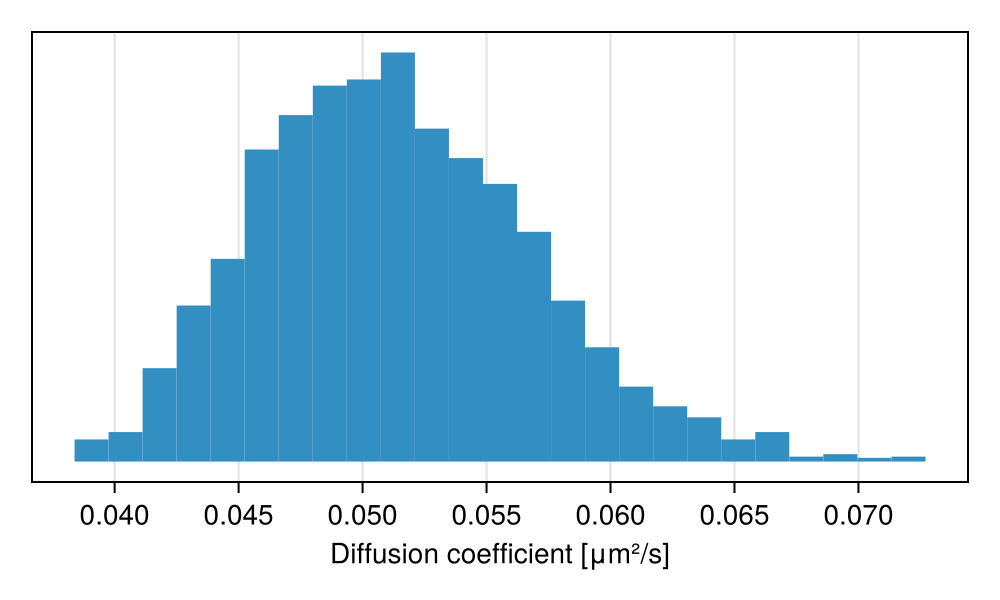

CairoMakie.Screen{IMAGE}


In [98]:
fig = Figure(size=(500, 300))
ax = Axis(fig[1,1],
    xlabel="Diffusion coefficient [μm²/s]",
    )
diff_coeff = chain.msds[burn_in:end] / (2*dt)
hist!(ax, diff_coeff, bins=25)
hideydecorations!(ax)
save("Fig_beads_D_posterior.pdf", fig)
display(fig)

In [81]:
track = chain.samples[end].tracks
println(size(track))

(750, 2, 3)


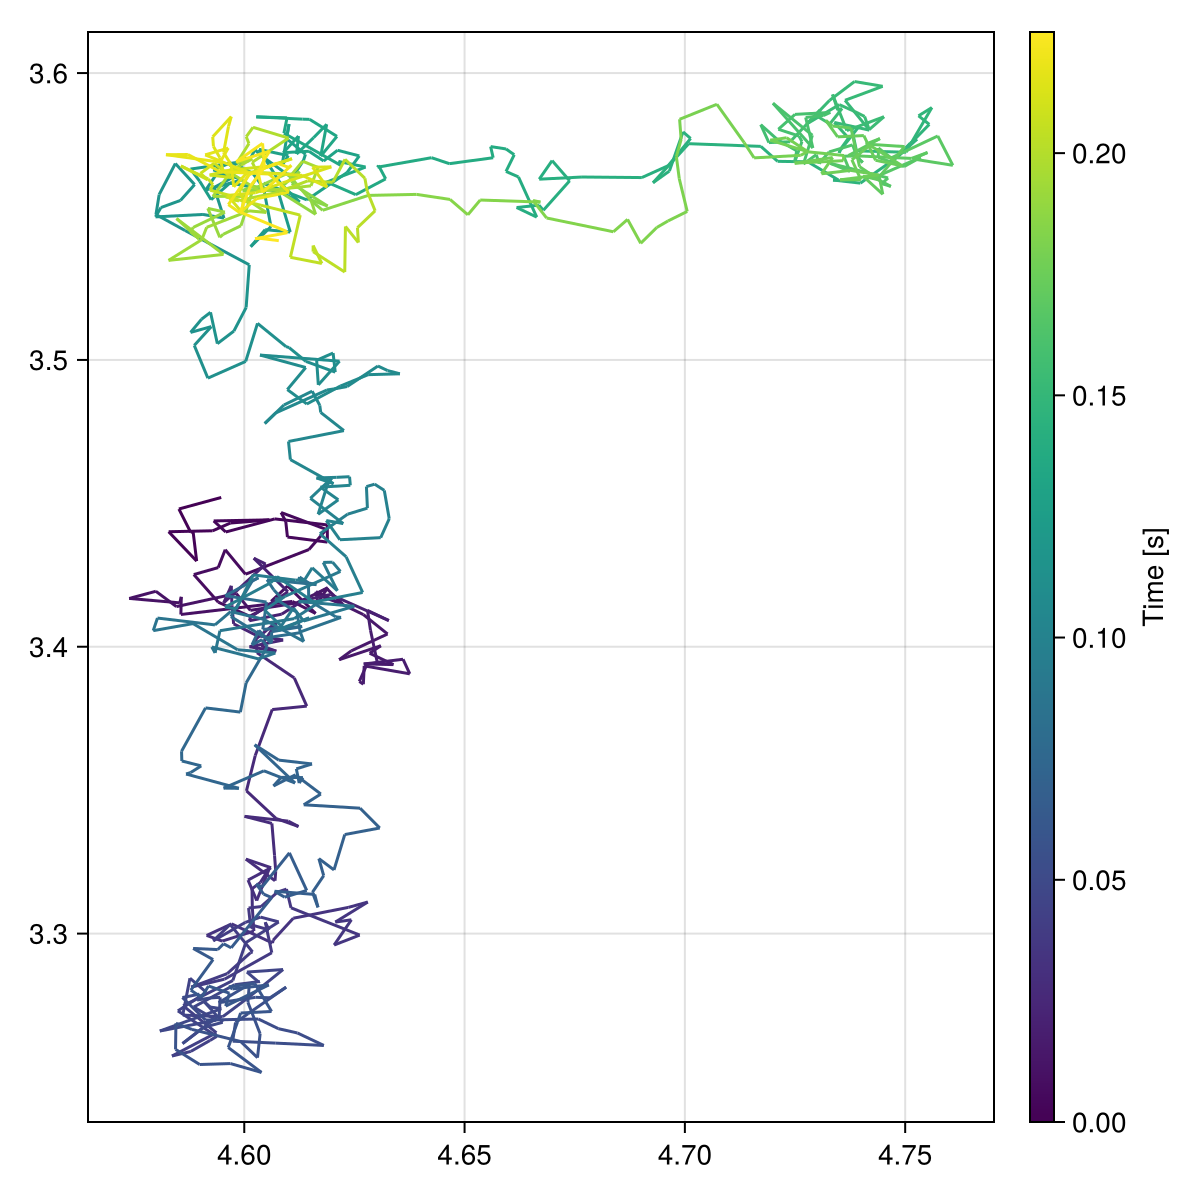

CairoMakie.Screen{IMAGE}


In [82]:
idx = 3
t = 0:dt:750*dt
fig = Figure(
    size=(600,600),
    aspect=DataAspect()
)
ax = Axis(fig[1,1])
traj = lines!(ax, track[:, 1, idx], track[:, 2, idx], color=t, colormap=:viridis)
Colorbar(fig[1,2], traj, label="Time [s]")
# scatter!(ax, track[1, :, idx]..., color=:red, markersize=10)
display(fig)

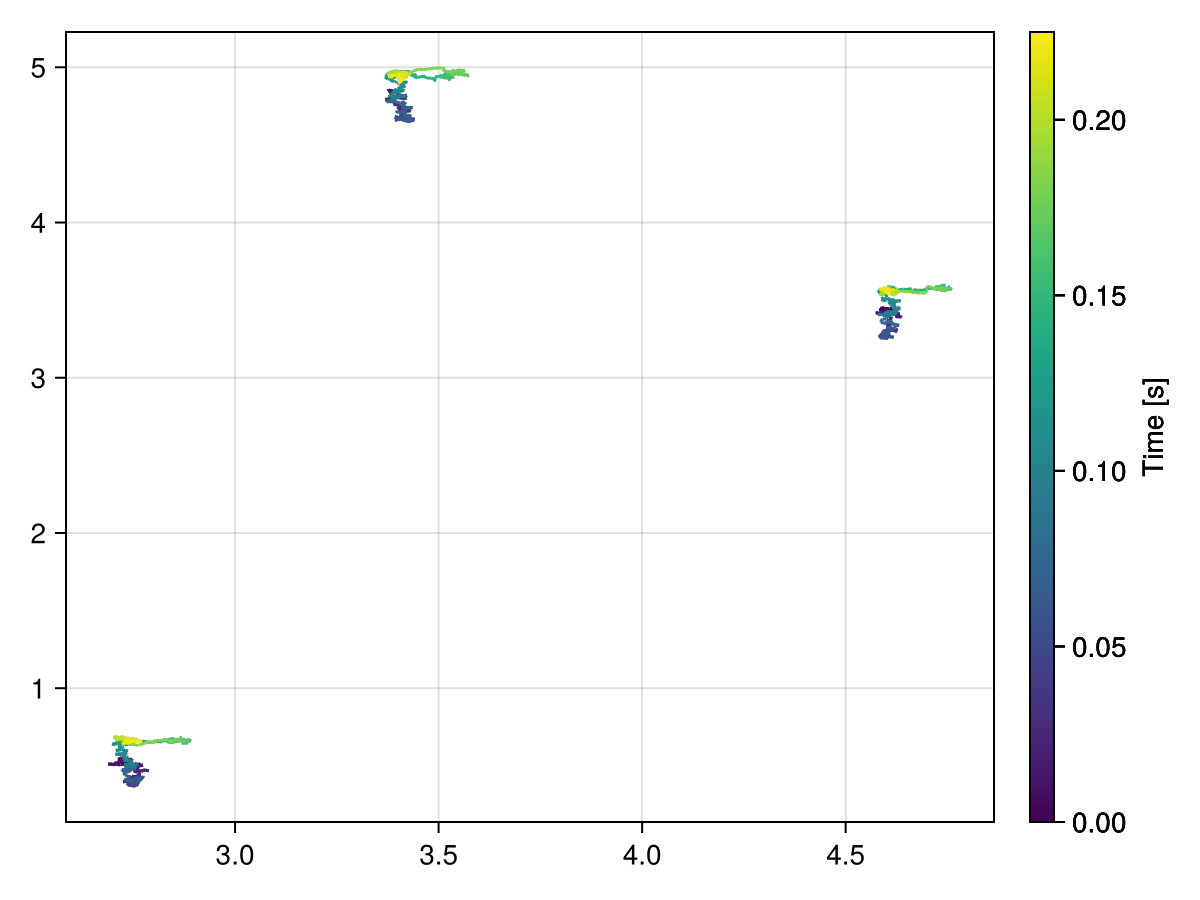

CairoMakie.Screen{IMAGE}


In [83]:
t = 0:dt:750*dt
fig = Figure(
    # size=(600,600),
    aspect=DataAspect()
)
ax = Axis(fig[1,1])
for idx in 1:3
    traj = lines!(ax, track[:, 1, idx], track[:, 2, idx], color=t, colormap=:viridis)
    Colorbar(fig[1,2], traj, label="Time [s]")
end
display(fig)

In [84]:
mean_track = zeros(size(track))
for i in burn_in:length(chain.samples)
    mean_track .+= chain.samples[i].tracks
end
mean_track ./= (length(chain.samples) - burn_in + 1);

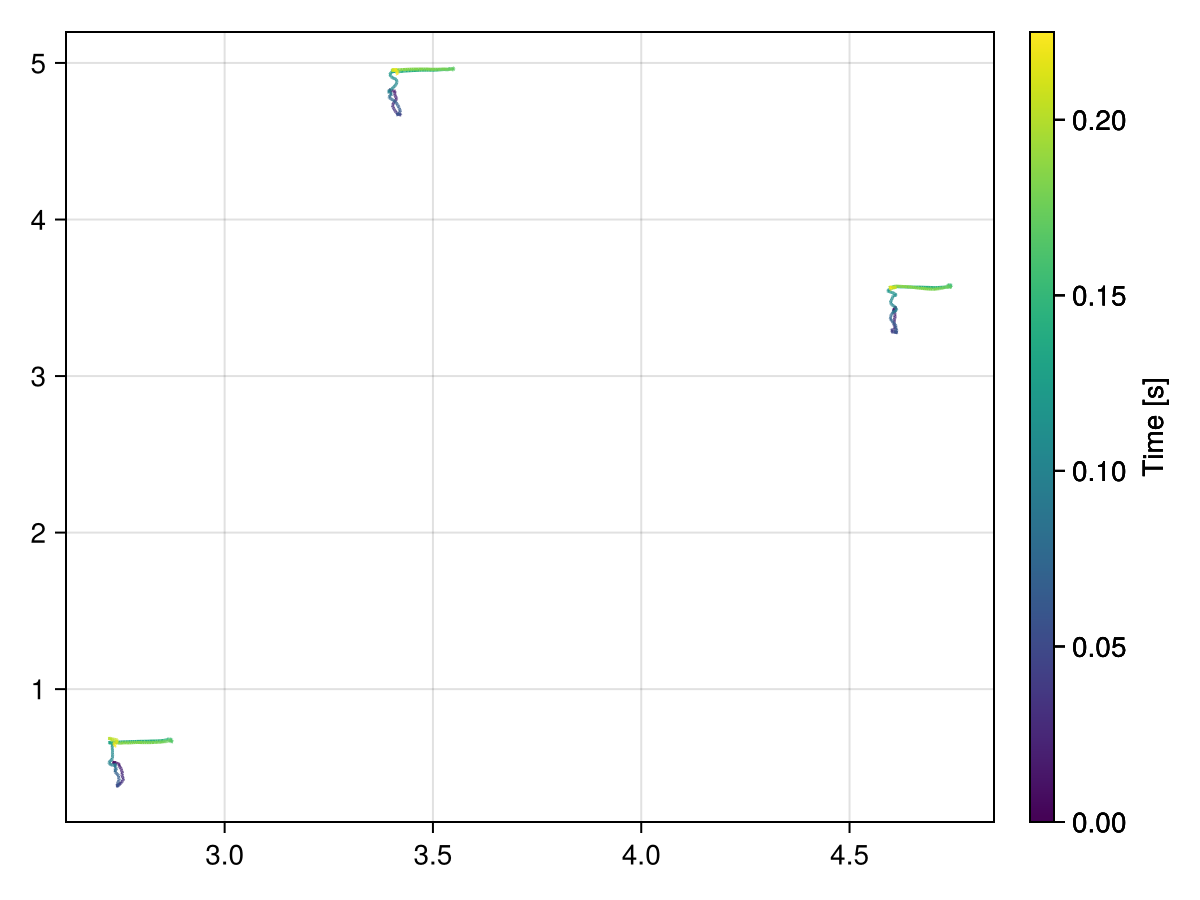

CairoMakie.Screen{IMAGE}


In [85]:
t = 0:dt:750*dt
fig = Figure(
    # size=(600,600),
    aspect=DataAspect()
)
ax = Axis(fig[1,1])
for idx in 1:3
    traj = lines!(ax, mean_track[:, 1, idx], mean_track[:, 2, idx], color=t, colormap=:viridis)
    Colorbar(fig[1,2], traj, label="Time [s]")
end
display(fig)

(750, 2, 3)


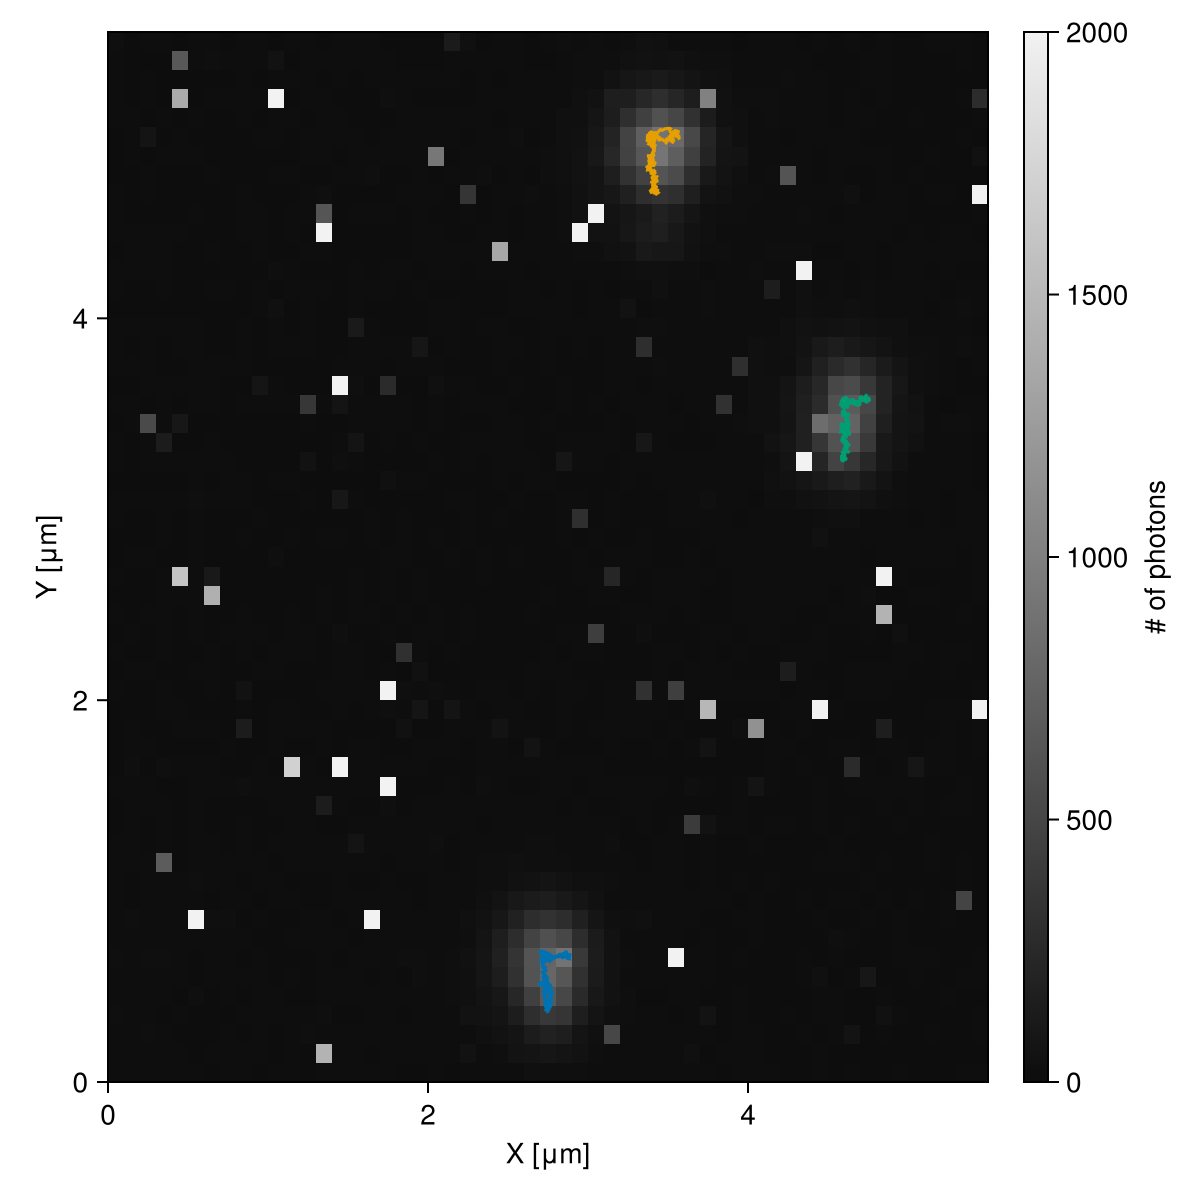

CairoMakie.Screen{IMAGE}


In [96]:
init_track = track = chain.samples[1].tracks
println(size(init_track))
track = chain.samples[end].tracks

# Swap two of the middle dimension
# init_track = init_track[:, [2, 1], :]

fig = Figure(
    size=(600,600),
    aspect=DataAspect()
)
x = (0:detector_size-1) .* pixel_size .+ pixel_size/2
y = (0:detector_size-1) .* pixel_size .+ pixel_size/2
ax = Axis(fig[1,1],
    xlabel="X [μm]",
    ylabel="Y [μm]",
)
hm = heatmap!(ax, x, y, dropdims(sum(frames, dims=3), dims=3), colormap=:grays, colorrange=(0, 2000), )
Colorbar(fig[1,2], hm, label="# of photons")
for idx in 1:3
    traj = lines!(ax, track[:, 1, idx], track[:, 2, idx], label="Track $idx")
    # traj = lines!(ax, init_track[:, 1, idx], init_track[:, 2, idx], label="Track $idx")
end
save("Fig_beads_traj_on_frames.pdf", fig)
display(fig)

(2

, 3)
(3,)(750, 2, 3)


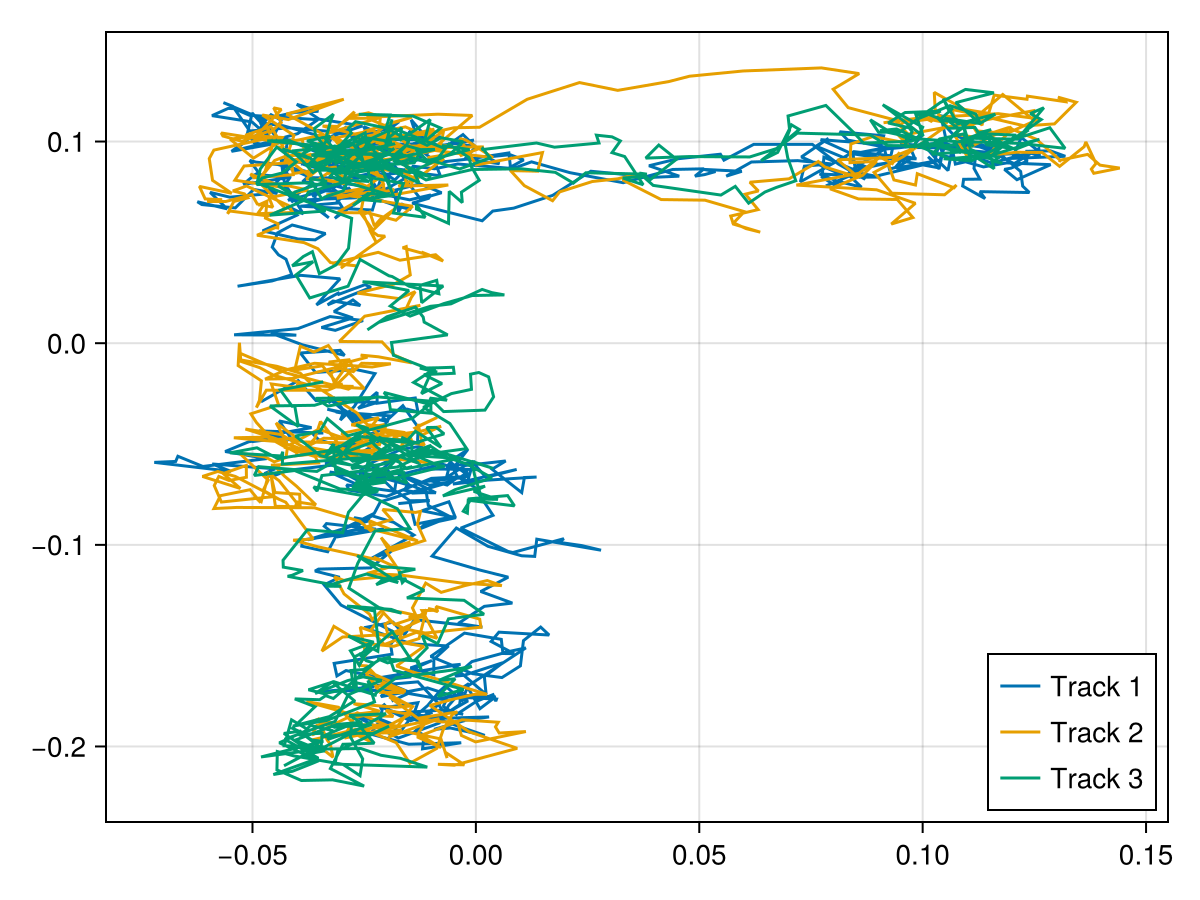

CairoMakie.Screen{IMAGE}


In [97]:
t = 0:dt:750*dt
track = chain.samples[end].tracks
fig = Figure(
    # size=(600,600),
    aspect=DataAspect()
)
ax = Axis(fig[1,1])
# alignment = [
#     [0.59, 2.59],
#     [4.59, 3.41],
#     [3.40, 4.79]
# ]
com = dropdims(mean(mean_track, dims=1), dims=1)
println(size(com))
println(size(alignment), size(track))
for idx in 1:3
    # lines!(ax, track[:, 1, idx] .- alignment[idx][1], track[:, 2, idx] .- alignment[idx][2], label="Track $idx")
    lines!(ax, track[:, 1, idx] .- com[1, idx], track[:, 2, idx] .- com[2, idx], label="Track $idx")
end
axislegend(position=:rb)
save("Fig_beads_traj_aligned.pdf", fig)
display(fig)

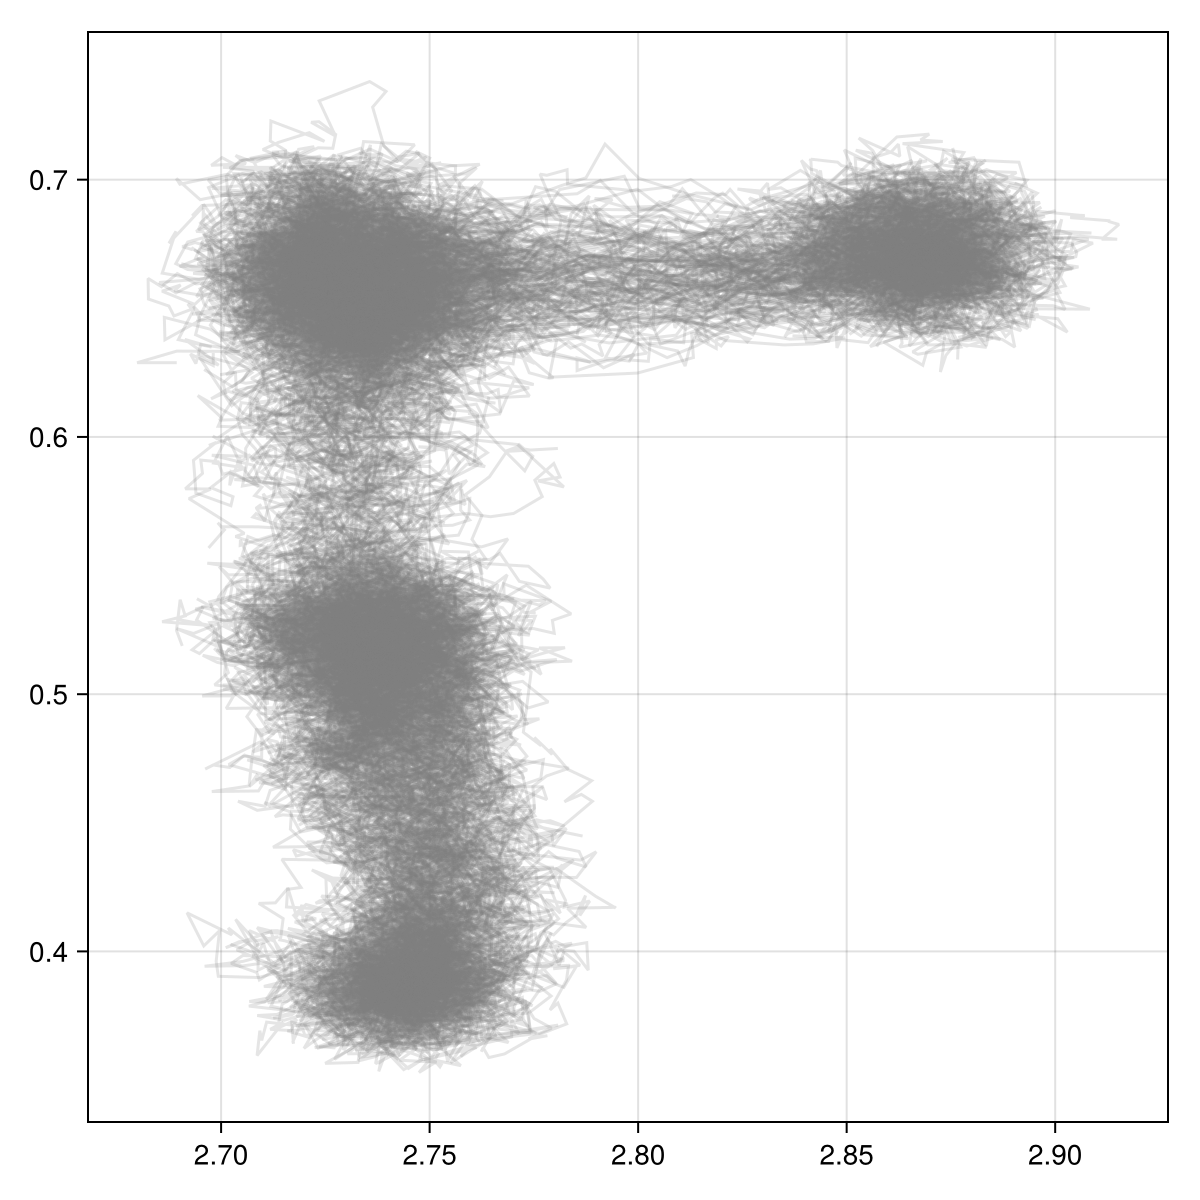

CairoMakie.Screen{IMAGE}


In [80]:
idx = 1
fig = Figure(
    size=(600,600),
    aspect=DataAspect()
)
ax = Axis(fig[1,1])
for j in burn_in:50:length(chain.samples)
    track_j = chain.samples[j].tracks[:, :, idx]
    traj = lines!(ax, track_j[:, 1], track_j[:, 2], color=:gray, alpha=0.2)
end
    # scatter!(ax, track[1, :, idx]..., color=:red, markersize=10)
display(fig)

## load trackmate tracks for initial guess

In [53]:
println(250/15, " ", 11250/15)
frames = load("./200nm_40ms_251_362_324x250p1_1.jld2", "frames")
println(size(frames))
pixel_size = 0.1
detector_size = 55

16.666666666666668 750.0
(55, 55, 11250)


55

In [58]:
# guess = xml2tracks("frames250_Tracks.xml", batchsize=1, nframes=45)
# println(size(guess))

guess = xml2tracks("frames250_Tracks.xml", batchsize=250, nframes=11250)
println(size(guess))

# guess = xml2tracks("frames250_Tracks.xml", batchsize=16, nframes=750)
# println(size(guess))

# guess = xml2tracks("frames250_Tracks.xml", batchsize=17, nframes=765)
# println(size(guess))

# guess_trim = guess[1:750,1:2, :]
# println(size(guess_trim))

guess = guess[:,1:2,:]
println(size(guess))
guess = guess[:, [2,1], :]

# guess = xml2tracks("frames250_Tracks.xml", batchsize=250, nframes=45)
# println(size(guess))

(11250, 3, 3)
(11250, 2, 3)


11250×2×3 Array{Float64, 3}:
[:, :, 1] =
 2.69219  0.51147
 2.69219  0.51147
 2.69219  0.51147
 2.69219  0.51147
 2.69219  0.51147
 2.69219  0.51147
 2.69219  0.51147
 2.69219  0.51147
 2.69219  0.51147
 2.69219  0.51147
 2.69219  0.51147
 2.69219  0.51147
 2.69219  0.51147
 ⋮        
 2.69082  0.628003
 2.69082  0.628003
 2.69082  0.628003
 2.69082  0.628003
 2.69082  0.628003
 2.69082  0.628003
 2.69082  0.628003
 2.69082  0.628003
 2.69082  0.628003
 2.69082  0.628003
 2.69082  0.628003
 2.69082  0.628003

[:, :, 2] =
 3.37848  4.80451
 3.37848  4.80451
 3.37848  4.80451
 3.37848  4.80451
 3.37848  4.80451
 3.37848  4.80451
 3.37848  4.80451
 3.37848  4.80451
 3.37848  4.80451
 3.37848  4.80451
 3.37848  4.80451
 3.37848  4.80451
 3.37848  4.80451
 ⋮        
 3.38061  4.89912
 3.38061  4.89912
 3.38061  4.89912
 3.38061  4.89912
 3.38061  4.89912
 3.38061  4.89912
 3.38061  4.89912
 3.38061  4.89912
 3.38061  4.89912
 3.38061  4.89912
 3.38061  4.89912
 3.38061  4.89912

[:, :, 3] =

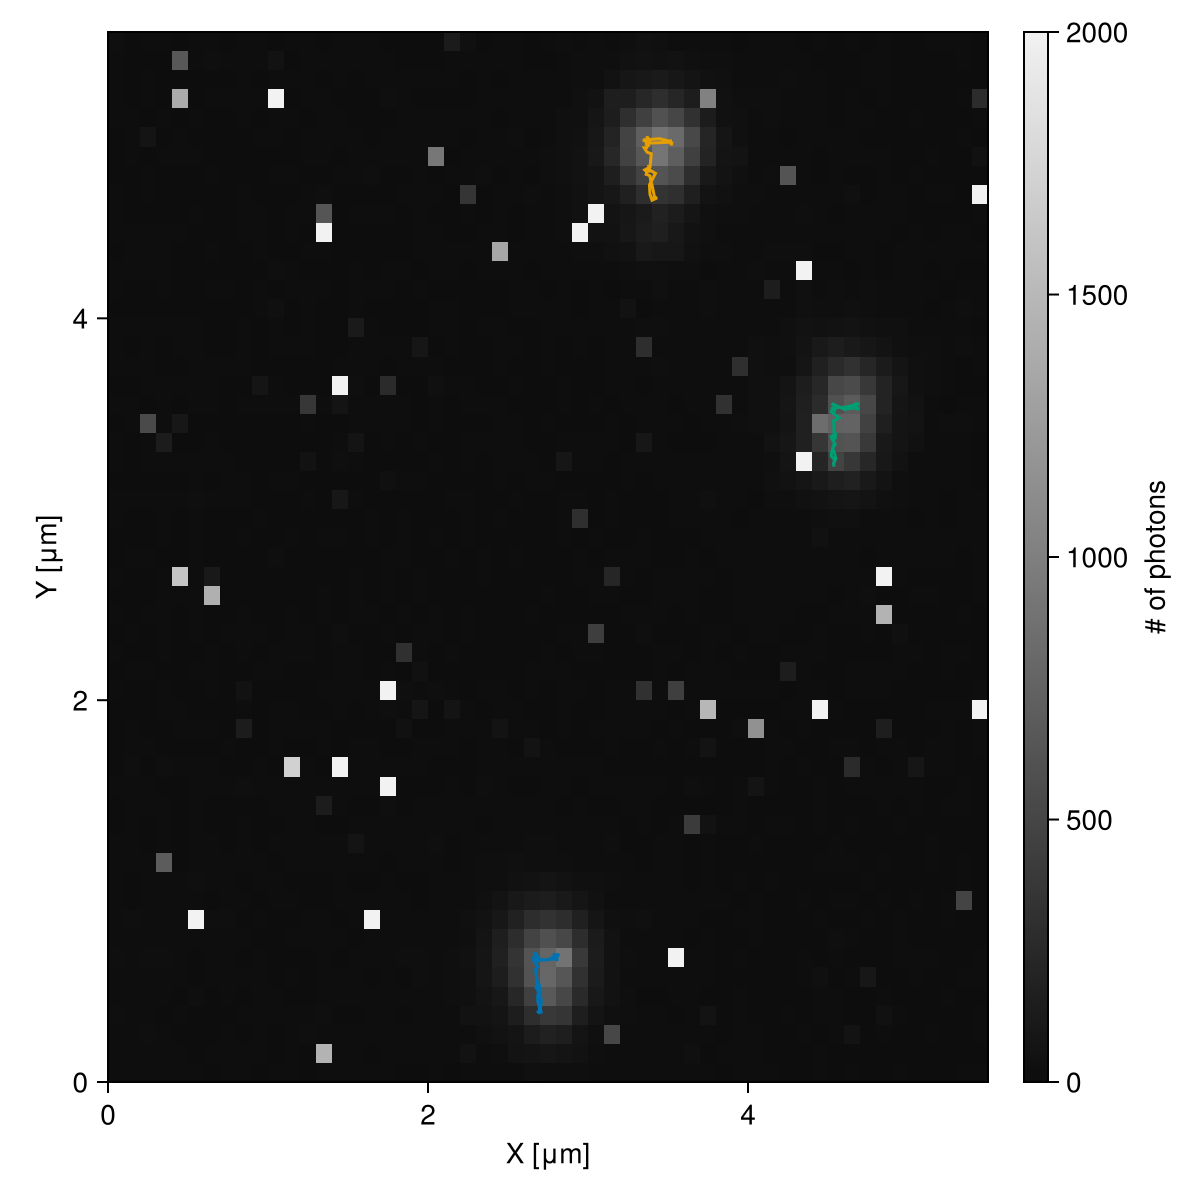

CairoMakie.Screen{IMAGE}


In [59]:

fig = Figure(
    size=(600,600),
    aspect=DataAspect()
)
x = (0:detector_size-1) .* pixel_size .+ pixel_size/2
y = (0:detector_size-1) .* pixel_size .+ pixel_size/2
ax = Axis(fig[1,1],
    xlabel="X [μm]",
    ylabel="Y [μm]",
)
hm = heatmap!(ax, x, y, dropdims(sum(frames, dims=3), dims=3), colormap=:grays, colorrange=(0, 2000), )
Colorbar(fig[1,2], hm, label="# of photons")
for idx in 1:3
    traj = lines!(ax, guess[:, 1, idx], guess[:, 2, idx], label="Track $idx")
end
display(fig)

In [60]:
jldsave("guess.jld2", tracks=guess)


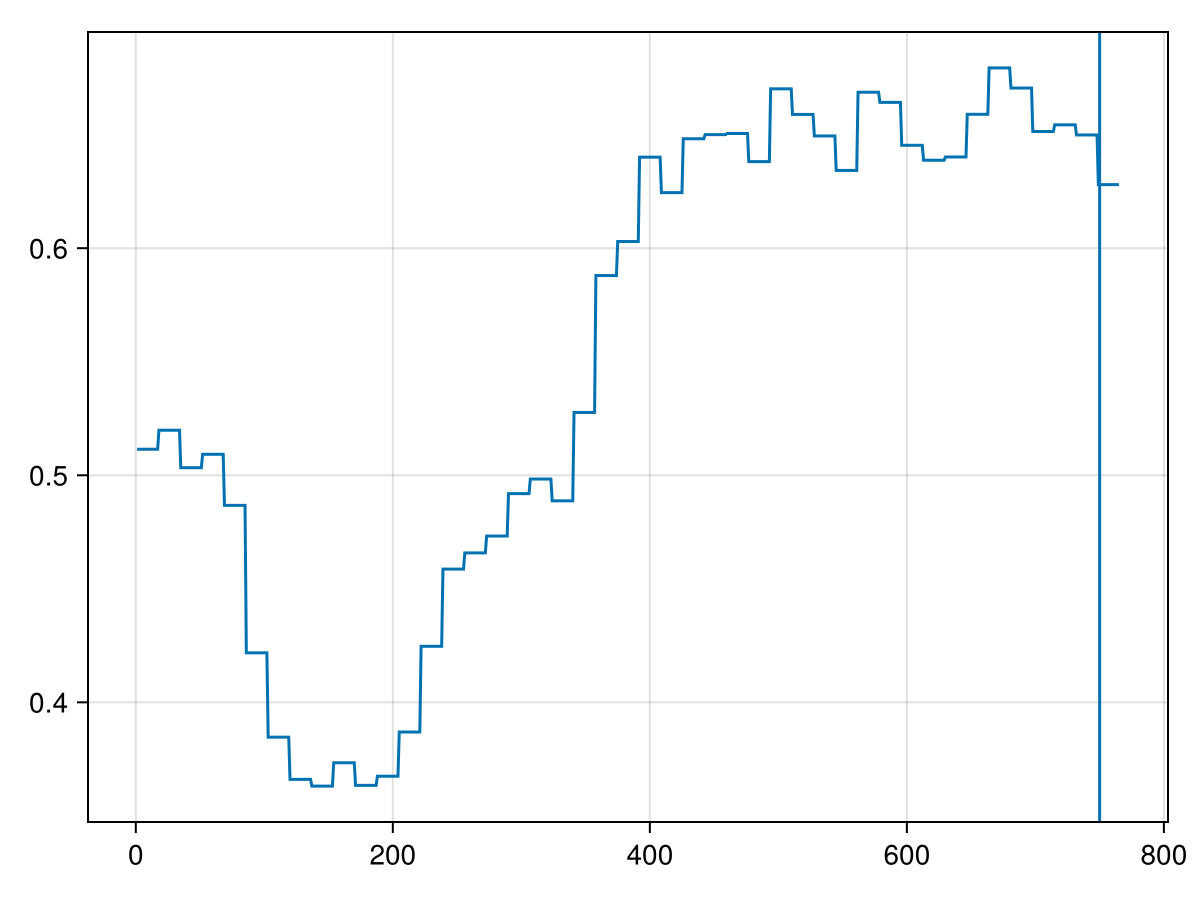

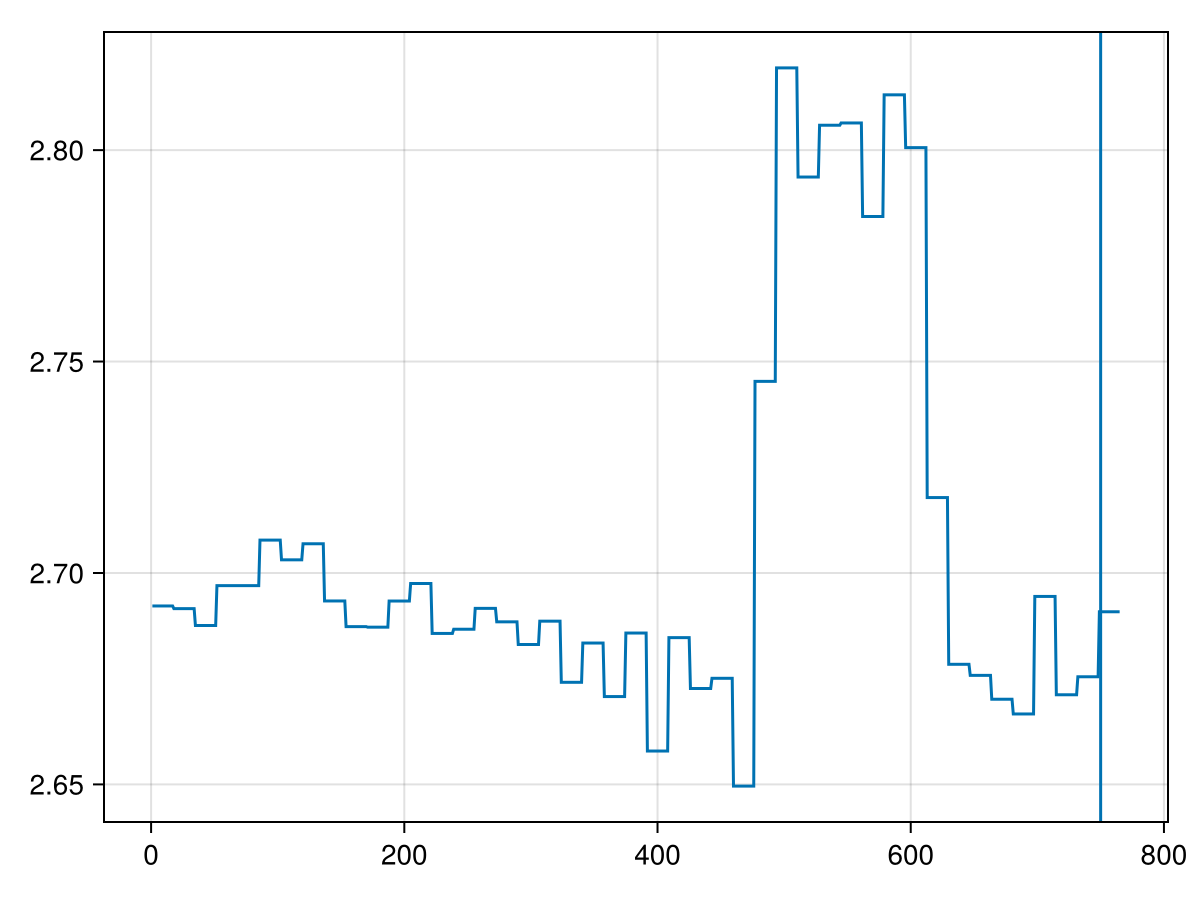

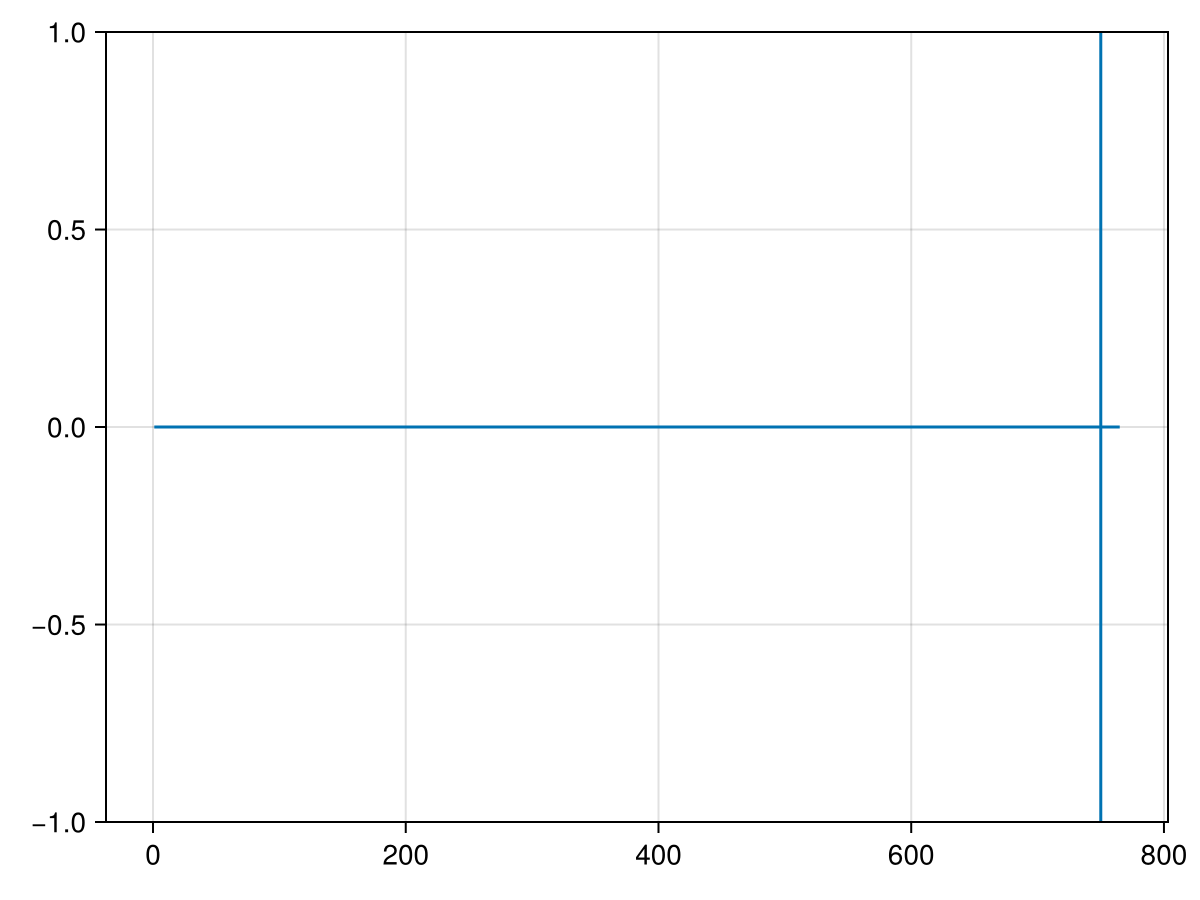

CairoMakie.Screen{IMAGE}


In [ ]:
fig = Figure()
ax = Axis(fig[1,1])
lines!(guess[:, 1, 1])
vlines!(750)
display(fig)

fig = Figure()
ax = Axis(fig[1,1])
lines!(guess[:, 2, 1])
vlines!(750)
display(fig)

fig = Figure()
ax = Axis(fig[1,1])
lines!(guess[:, 3, 1])
vlines!(750)
display(fig)

## Look at darkcounts

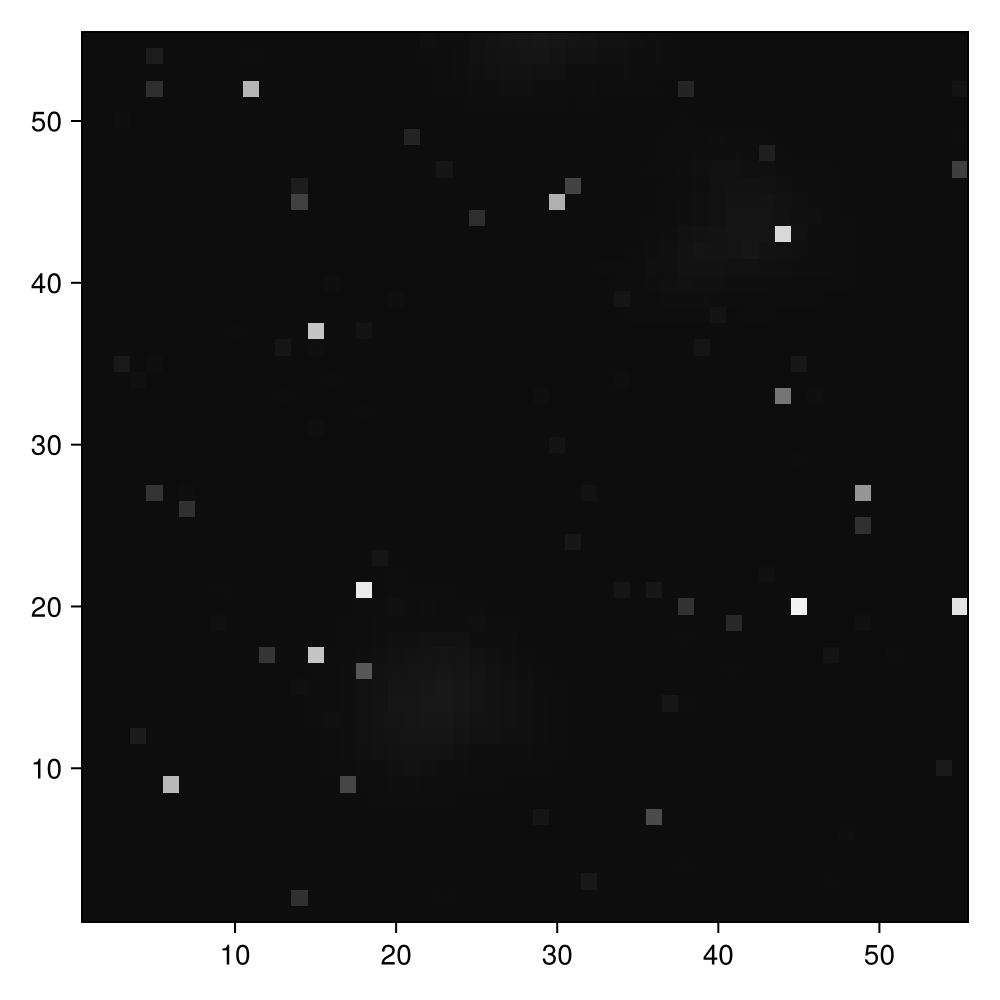

CairoMakie.Screen{IMAGE}


In [ ]:
darkcounts = load("darkcounts.jld2", "darkcounts")

fig = Figure(size=(500,500))
ax = Axis(fig[1,1])
heatmap!(ax, darkcounts, colormap=:grays)
display(fig)